In [57]:
import numpy  as np
import matplotlib.pyplot as plt
import cv2 

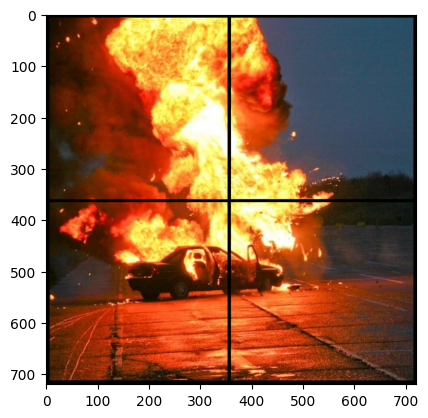

In [80]:
bom = cv2.imread("Assets/Meledak.png")
bom = cv2.cvtColor(bom, cv2.COLOR_BGR2RGB)
windut = cv2.imread("Assets/Windut.png")
windut = cv2.cvtColor(windut, cv2.COLOR_BGR2RGB)
bureng = cv2.imread("Assets/Bunga.png")
bureng = cv2.cvtColor(bureng, cv2.COLOR_BGR2RGB)
sky = cv2.imread("Assets/Langit.png")
sky = cv2.cvtColor(sky, cv2.COLOR_BGR2RGB)
plt.imshow(bom,cmap='gray')

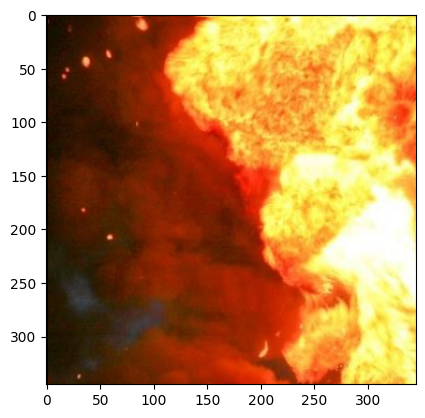

In [8]:
potong1 = bom [5:350 , 5:350]
plt.imshow(potong1, cmap='gray')

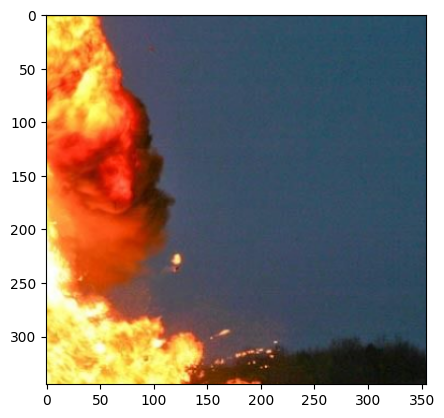

In [13]:
potong2 = bom [5:350 , 360:715]
plt.imshow(potong2, cmap='gray')

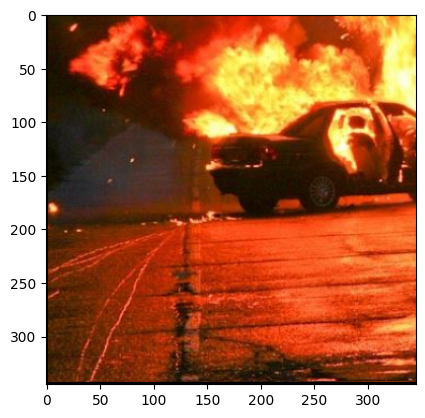

In [16]:
potong3 = bom [370:715 , 5:350]
plt.imshow(potong3, cmap='gray')

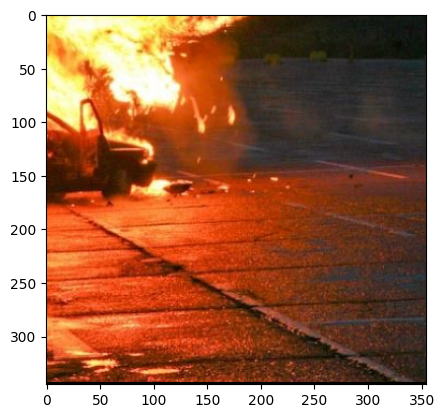

In [17]:
potong4 = bom [370:715 ,360:715]
plt.imshow(potong4, cmap='gray')

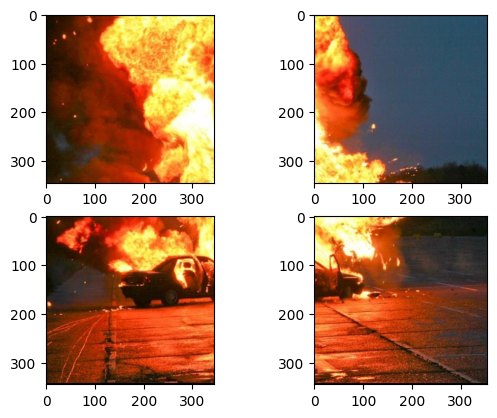

In [19]:
plt.subplot(2,2,1)
plt.imshow(potong1, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(potong2, cmap='gray')
plt.subplot(2,2,3)
plt.imshow(potong3, cmap='gray')
plt.subplot(2,2,4)
plt.imshow(potong4, cmap='gray')

In [24]:
def merge_image(image1, image2, orientation='H'):

    # Horizontal merge
    if orientation == 'H':

        height = max(image1.shape[0], image2.shape[0])
        total_width = image1.shape[1] + image2.shape[1]

        # Grayscale image
        if len(image1.shape) == 2:
            merged = np.zeros((height, total_width), dtype=image1.dtype)

        # Color image
        else:
            merged = np.zeros(
                (height, total_width, image1.shape[2]),
                dtype=image1.dtype
            )

        # Place first image
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1

        # Place second image
        merged[
            0:image2.shape[0],
            image1.shape[1]:image1.shape[1] + image2.shape[1]
        ] = image2

    # Vertical merge
    else:

        total_height = image1.shape[0] + image2.shape[0]
        width = max(image1.shape[1], image2.shape[1])

        # Grayscale image
        if len(image1.shape) == 2:
            merged = np.zeros((total_height, width), dtype=image1.dtype)

        # Color image
        else:
            merged = np.zeros(
                (total_height, width, image1.shape[2]),
                dtype=image1.dtype
            )

        # Place first image
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1

        # Place second image
        merged[
            image1.shape[0]:image1.shape[0] + image2.shape[0],
            0:image2.shape[1]
        ] = image2

    return merged

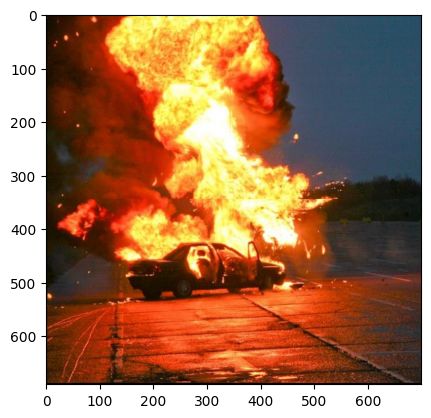

In [26]:
gabung1 = merge_image(potong1, potong2, 'H')
gabung2 = merge_image(potong3, potong4, 'H')
gabungan = merge_image(gabung1, gabung2, 'V')

plt.imshow(gabungan, cmap="gray")


(690, 700)

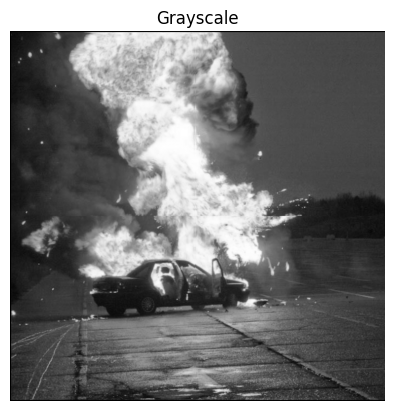

In [49]:
abu = np.zeros((gabungan.shape[0], gabungan.shape[1]),dtype=np.uint8)
for i in range(gabungan.shape[0]):
    for j in range(gabungan.shape[1]):
        r, g, b = gabungan[i, j]
        abu[i, j] = int(0.299*r + 0.587*g + 0.114*b)

plt.imshow(abu, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
abu.shape

In [29]:
def ekualisasi(citra):

    height, width = citra.shape

    # Histogram
    hist = np.zeros(256, dtype=int)

    # Hitung histogram citra
    for i in range(height):
        for j in range(width):

            pixel = citra[i, j]
            hist[pixel] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)

    cdf[0] = hist[0]

    # Hitung CDF
    for i in range(1, 256):

        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    # Hasil ekualisasi
    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Terapkan hasil CDF normalisasi
    for i in range(height):
        for j in range(width):

            pixel = citra[i, j]
            hasil[i, j] = cdf_normal[pixel]

    return hasil

Text(0.5, 1.0, 'Ekualisasi')

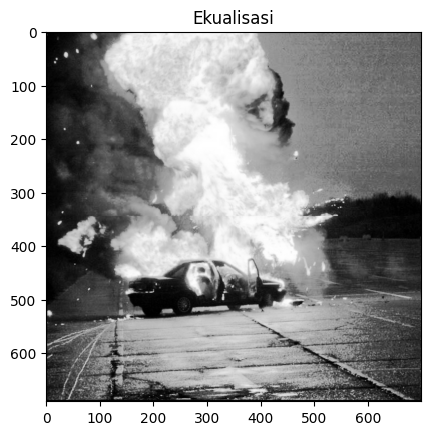

In [31]:
equal=ekualisasi(abu)
plt.imshow(equal, cmap='gray')
plt.title("Ekualisasi")

In [32]:
def histo(image):
    histogram = [0] * 256

    height = len(image)
    width = len(image[0]) if height > 0 else 0

    for i in range(height):
        for j in range(width):
            val = int(image[i][j])
            histogram[val] += 1

    return histogram


def plot_histo(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))

    plt.xlabel("Pixel Intensity")
    plt.ylabel("Number of Pixels")
    plt.title(title)

    plt.bar(range(256), histogram, color=ImgColor, width=0.8)

    plt.show()

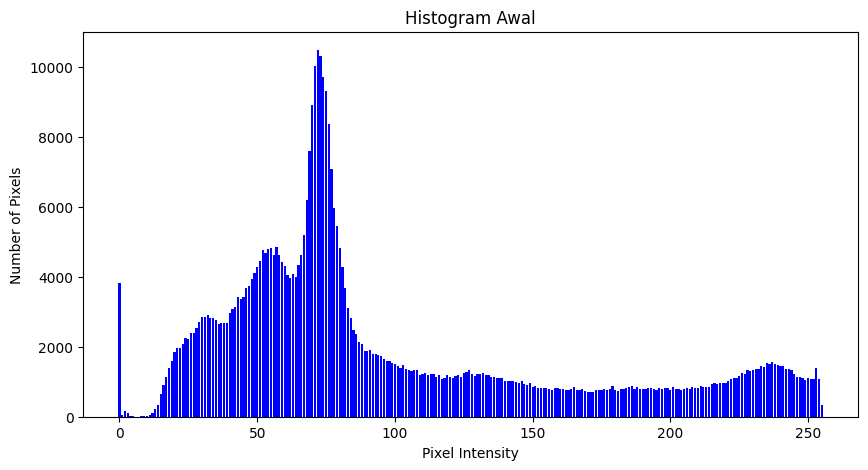

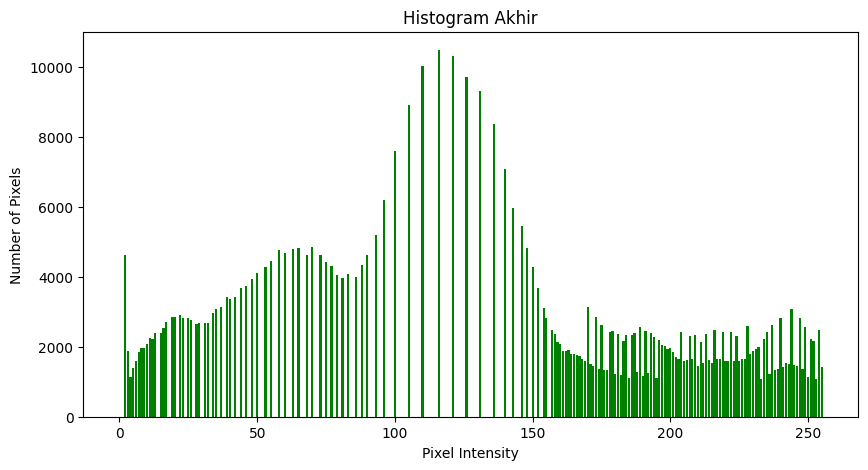

In [35]:
histowal = histo(abu)
histoeq  = histo(equal)
plot_histo(histowal, "Histogram Awal", "blue")
plot_histo(histoeq, "Histogram Akhir", "green")

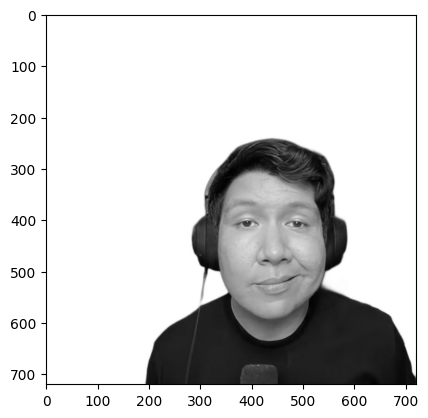

In [38]:
winbu = np.zeros((windut.shape[0], windut.shape[1]),dtype=np.uint8)
for i in range(windut.shape[0]):
    for j in range(windut.shape[1]):
        r, g, b = windut[i, j]
        winbu[i, j] = int(0.299*r + 0.587*g + 0.114*b)
plt.imshow(winbu, cmap="gray")

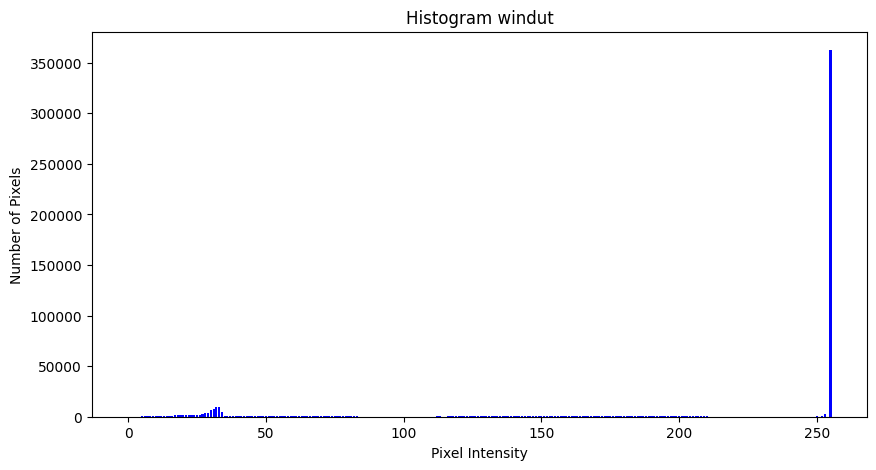

In [ ]:
winto = histo(winbu)
plot_histo(winto, "Histogram windut", "blue")

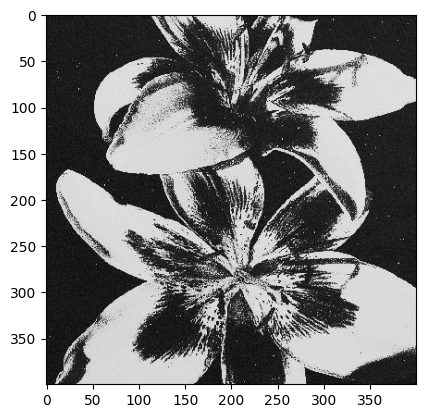

In [42]:
bubu = np.zeros((bureng.shape[0], bureng.shape[1]),dtype=np.uint8)
for i in range(bureng.shape[0]):
    for j in range(bureng.shape[1]):
        r, g, b = bureng[i, j]
        bubu[i, j] = int(0.299*r + 0.587*g + 0.114*b)
plt.imshow(bubu, cmap="gray")

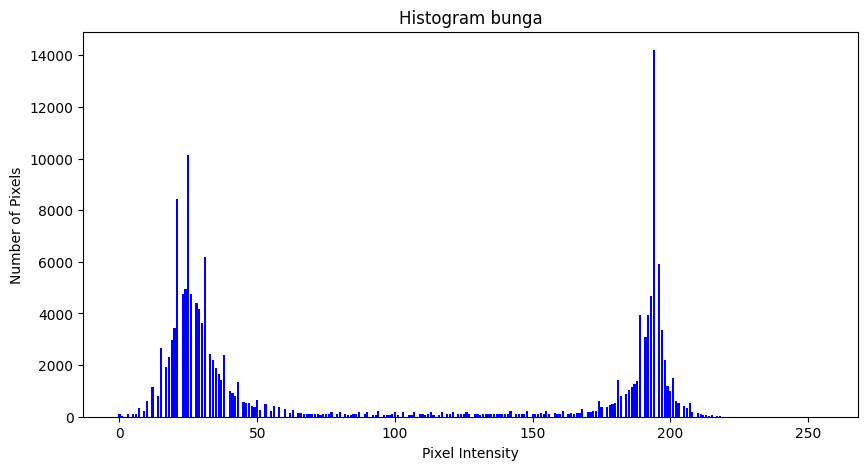

In [47]:
buto = histo(bubu)
plot_histo(buto, "Histogram bunga", "blue")

In [43]:
def spec(source_image, target_image):

    hist_source = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    # Compute histogram of source image
    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            pixel_value = source_image[i, j]
            hist_source[pixel_value] += 1

    # Compute histogram of target image
    for i in range(target_image.shape[0]):
        for j in range(target_image.shape[1]):
            pixel_value = target_image[i, j]
            hist_target[pixel_value] += 1

    cdf_source = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_source[0] = hist_source[0]
    cdf_target[0] = hist_target[0]

    # Compute CDF
    for i in range(1, 256):
        cdf_source[i] = cdf_source[i - 1] + hist_source[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    # Normalize CDF
    cdf_source = cdf_source / cdf_source[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    # Histogram mapping
    for i in range(256):

        diff = np.abs(cdf_target - cdf_source[i])

        # Find index with smallest difference
        j = np.argmin(diff)

        map_hist[i] = j

    height, width = source_image.shape

    result = np.zeros((height, width), dtype=np.uint8)

    # Apply mapping to source image
    for i in range(height):
        for j in range(width):
            result[i, j] = map_hist[source_image[i, j]]

    return result

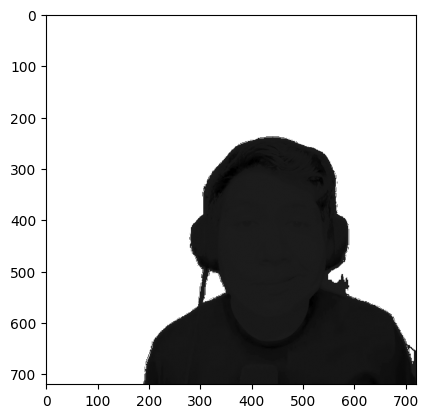

In [44]:
spec1 = spec(winbu, bubu)
plt.imshow(spec1, cmap = "gray")

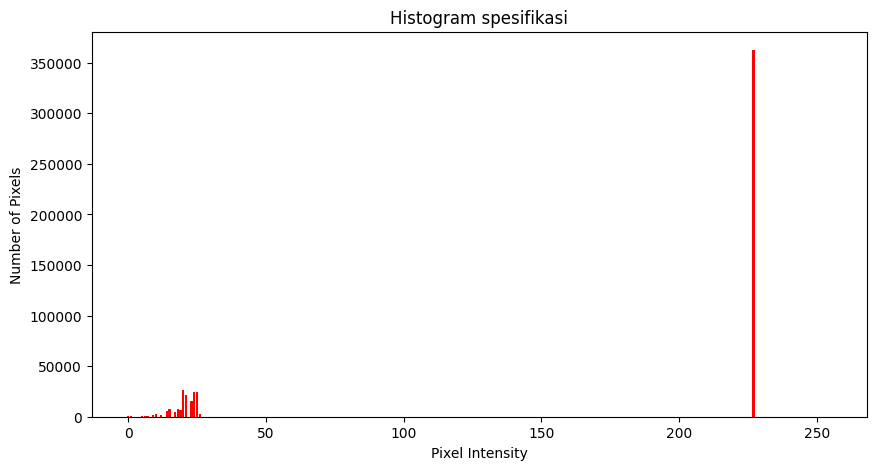

In [48]:
winbuto = histo(spec1)
plot_histo(winbuto, "Histogram spesifikasi", "red")

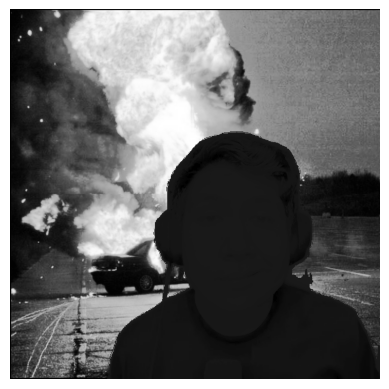

In [64]:
bg = cv2.resize (equal,(spec1.shape[1],spec1.shape[0]))
result = np.zeros_like(bom)

for i in range(spec1.shape[0]):
    for j in range(spec1.shape[1]):
        if spec1[i, j] > 200:
            result[i, j] = bg[i, j]
        else:
            result[i, j] = spec1[i, j]
plt.imshow(result, cmap="gray")
plt.axis("off")
plt.show()

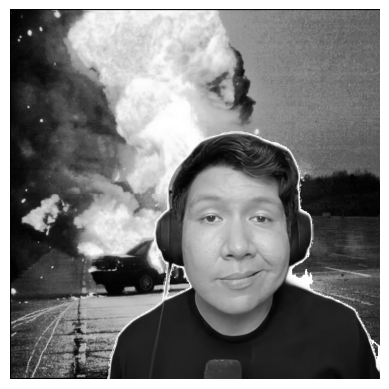

In [79]:
bg = cv2.resize (result,(winbu.shape[1],winbu.shape[0]))
result2 = np.zeros_like(bom)

for i in range(winbu.shape[0]):
    for j in range(winbu.shape[1]):
        if winbu[i, j] > 254:
            result2[i, j] = bg[i, j]
        else:
            result2[i, j] = winbu[i, j]
plt.imshow(result2, cmap="gray")
plt.axis("off")
plt.show()

(490, 735)

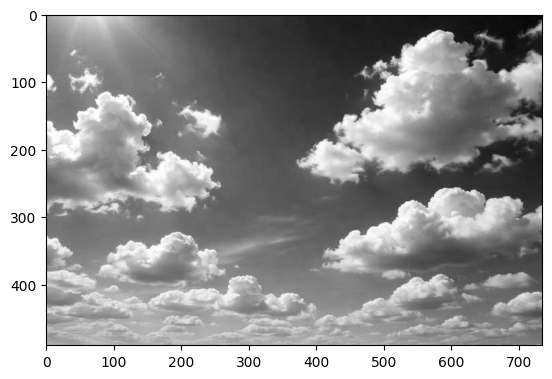

In [86]:
skybu = np.zeros((sky.shape[0], sky.shape[1]),dtype=np.uint8)
for i in range(sky.shape[0]):
    for j in range(sky.shape[1]):
        r, g, b = sky[i, j]
        skybu[i, j] = int(0.299*r + 0.587*g + 0.114*b)
plt.imshow(skybu, cmap="gray")
skybu.shape

In [85]:
spec2 = spec(result2, skybu)
plt.imshow(spec2)

ValueError: too many values to unpack (expected 2, got 3)